# Prompt Chaining with LangGraph

## Theory

**Prompt chaining** breaks a complex task into a sequence of focused LLM calls where
each step's output becomes the next step's structured input.

### Why a single prompt fails for complex tasks

Asking one prompt to research + draft + edit + quality-check all at once overloads
the model's attention. It trades depth for breadth and produces mediocre work at every stage.

Chaining fixes this by giving each LLM call ONE clear job with ONE clear output format.

### The three rules of good prompt chains

| Rule | What it means |
|---|---|
| One job per step | Each prompt does exactly one thing |
| Structured handoff | Output of step N is explicitly formatted as input for step N+1 |
| Gate before continuing | A quality check can loop back rather than pass bad output forward |

### Scenario in this notebook
A 4-step blog post pipeline:
```
research_topic → write_draft → quality_check → format_output
                     ↑               |
                     └── revise ─────┘  (if quality score < threshold)
```
The quality gate is the key difference from a plain sequential pipeline.
If the draft is weak, the critique is injected back into `write_draft` as context.

In [1]:
# ── Imports ───────────────────────────────────────────────
from typing import TypedDict, Optional, Literal
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from IPython.display import Image, display
from dotenv import load_dotenv
import json, os

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

llm = ChatOpenAI(model="gpt-4o", temperature=0.4)

In [2]:
# ── State ─────────────────────────────────────────────────
# State accumulates as the chain progresses.
# Each node reads upstream fields and writes its own output field.
# Nothing is lost — every intermediate result is inspectable.

class BlogState(TypedDict):
    # Input
    topic: str                   # The blog topic the user provides
    target_audience: str         # Who the article is for
    word_count: int              # Approximate target word count

    # Chain outputs — each node fills one of these
    research_notes: Optional[str]    # Step 1 output: structured facts
    draft: Optional[str]             # Step 2 output: full article draft
    quality_score: Optional[int]     # Step 3 output: 1-10 score
    quality_critique: Optional[str]  # Step 3 output: detailed critique
    final_article: Optional[str]     # Step 4 output: formatted article

    # Control
    revision_count: int          # How many times write_draft has run
    max_revisions: int           # Safety ceiling to prevent infinite loops

In [3]:
# ── Step 1: research_topic ────────────────────────────────
# SINGLE JOB: Gather facts about the topic.
# OUTPUT FORMAT: Numbered list of specific, verifiable facts.
#
# Key design choice: we ask for a structured list, NOT prose.
# Prose from step 1 would be hard for step 2 to consume cleanly.
# A numbered list is easy to inject directly into the draft prompt.

def research_topic(state: BlogState) -> BlogState:
    print(f"\n[Step 1] Researching: '{state['topic']}'")

    prompt = f"""You are a research assistant. Your ONLY job is to gather facts.

Topic: {state['topic']}
Target audience: {state['target_audience']}

Produce a numbered list of exactly 8 specific, interesting facts about this topic.
Rules:
- Each fact must be on its own line, numbered 1-8
- Each fact must be concrete and specific (no vague generalisations)
- Include at least 2 surprising or counterintuitive facts
- No prose, no headings, no introduction — just the numbered list
"""

    response = llm.invoke([HumanMessage(content=prompt)])
    notes = response.content.strip()

    print(f"[Step 1] Research complete — {len(notes.splitlines())} facts gathered")
    return {**state, "research_notes": notes}

In [4]:
# ── Step 2: write_draft ───────────────────────────────────
# SINGLE JOB: Write a blog post draft using the research notes.
# INPUT: research_notes (structured facts from step 1)
#        quality_critique (injected on revision rounds)
#
# Key design choice: when revising, we inject the FULL critique
# from the quality check. This is the "chain feedback loop" —
# the output of a downstream step flows back into an upstream step.

def write_draft(state: BlogState) -> BlogState:
    revision = state["revision_count"]
    print(f"\n[Step 2] Writing draft (revision {revision + 1})")

    # On revision rounds, inject the critique as a correction instruction
    critique_section = ""
    if state.get("quality_critique") and revision > 0:
        critique_section = f"""
IMPORTANT — This is revision #{revision}. Your previous draft was rejected.
Here is the critique you MUST address in this revision:

{state['quality_critique']}

Fix ALL the issues above while keeping the good parts.
"""

    prompt = f"""You are an expert blog writer. Your ONLY job is to write a draft.

Topic: {state['topic']}
Target audience: {state['target_audience']}
Target word count: approximately {state['word_count']} words

Research notes to base the article on:
{state['research_notes']}
{critique_section}
Write a complete, engaging blog post. Include:
- A compelling headline
- An opening hook that grabs attention
- Clear sections with subheadings
- A strong conclusion with a takeaway

Use ALL 8 research facts naturally within the article.
Do not add a word count label. Write the article only.
"""

    response = llm.invoke([HumanMessage(content=prompt)])
    draft = response.content.strip()
    word_count = len(draft.split())

    print(f"[Step 2] Draft written — {word_count} words")
    return {
        **state,
        "draft": draft,
        "revision_count": revision + 1
    }

In [5]:
# ── Step 3: quality_check ─────────────────────────────────
# SINGLE JOB: Score the draft and produce a detailed critique.
# OUTPUT FORMAT: JSON with score + critique (so the router can parse it cleanly)
#
# Key design choice: we ask for JSON output so the score is
# machine-readable. The router reads state["quality_score"] to decide
# whether to loop back or continue. No string parsing needed.

def quality_check(state: BlogState) -> BlogState:
    print(f"\n[Step 3] Running quality check on draft")

    prompt = f"""You are a senior editor. Your ONLY job is to evaluate this draft.

Topic: {state['topic']}
Target audience: {state['target_audience']}

Draft to evaluate:
{state['draft']}

Score this draft on these 4 dimensions (1-10 each):
1. Clarity — Is it easy to read and understand?
2. Engagement — Does it hold attention from start to finish?
3. Accuracy — Are the facts used correctly and specifically?
4. Structure — Does it have a clear flow with good headings?

Reply with ONLY this JSON — nothing else, no markdown code fences:
{{
  "clarity": <1-10>,
  "engagement": <1-10>,
  "accuracy": <1-10>,
  "structure": <1-10>,
  "overall": <average of above, rounded to nearest int>,
  "critique": "<specific, actionable feedback — what to fix and how, 3-5 sentences>",
  "strengths": "<what is already working well, 1-2 sentences>"
}}
"""

    response = llm.invoke([HumanMessage(content=prompt)])

    try:
        result = json.loads(response.content.strip())
        score   = int(result["overall"])
        critique = (
            f"Scores — Clarity: {result['clarity']}/10, "
            f"Engagement: {result['engagement']}/10, "
            f"Accuracy: {result['accuracy']}/10, "
            f"Structure: {result['structure']}/10\n\n"
            f"Strengths: {result['strengths']}\n\n"
            f"What to fix: {result['critique']}"
        )
    except (json.JSONDecodeError, KeyError):
        # Fallback if LLM doesn't return clean JSON
        score   = 6
        critique = response.content.strip()

    print(f"[Step 3] Quality score: {score}/10")
    return {
        **state,
        "quality_score": score,
        "quality_critique": critique
    }

In [6]:
# ── Step 4: format_output ─────────────────────────────────
# SINGLE JOB: Final polish and formatting.
# INPUT: The approved draft (score >= threshold)
#
# This step adds SEO metadata, fixes minor phrasing, and
# produces the publication-ready version.
# It does NOT rewrite — that's write_draft's job.

def format_output(state: BlogState) -> BlogState:
    print(f"\n[Step 4] Formatting final output")

    prompt = f"""You are a content editor doing final polish. Your ONLY job is formatting.

Take this approved draft and produce the publication-ready version:

{state['draft']}

Your tasks (do NOT rewrite or change substance):
1. Fix any minor grammatical or punctuation issues
2. Ensure all subheadings use consistent formatting (## for H2)
3. Add a meta description (1 sentence, max 160 chars) at the very top labelled: Meta:
4. Add suggested tags at the bottom labelled: Tags: (comma-separated, 4-6 tags)
5. Add estimated read time at the top labelled: Read time: (e.g. "4 min read")

Output the complete formatted article. Nothing else.
"""

    response = llm.invoke([HumanMessage(content=prompt)])
    final = response.content.strip()

    print(f"[Step 4] Article ready — {len(final.split())} words")
    return {**state, "final_article": final}

In [7]:
# ── Router: should_revise ─────────────────────────────────
# This is the quality gate — the heart of what makes this
# a chain rather than a simple pipeline.
#
# Decision logic:
#   score >= 7  → pass → format_output
#   score < 7   → fail → write_draft (with critique injected)
#   max revisions hit → force pass to avoid infinite loop

QUALITY_THRESHOLD = 7  # Minimum score to pass quality gate

def should_revise(
    state: BlogState
) -> Literal["write_draft", "format_output"]:
    score    = state.get("quality_score", 0)
    revisions = state.get("revision_count", 0)
    max_rev  = state.get("max_revisions", 2)

    if revisions >= max_rev:
        print(f"[Router] Max revisions ({max_rev}) reached — forcing pass")
        return "format_output"

    if score >= QUALITY_THRESHOLD:
        print(f"[Router] Score {score}/10 >= {QUALITY_THRESHOLD} — PASS → format_output")
        return "format_output"
    else:
        print(f"[Router] Score {score}/10 < {QUALITY_THRESHOLD} — FAIL → revise")
        return "write_draft"

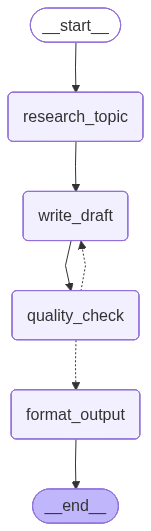

In [8]:
# ── Graph Construction ─────────────────────────────────────
def build_blog_chain():
    builder = StateGraph(BlogState)

    # Register all nodes
    builder.add_node("research_topic", research_topic)
    builder.add_node("write_draft",    write_draft)
    builder.add_node("quality_check",  quality_check)
    builder.add_node("format_output",  format_output)

    # Linear chain: START → research → draft → quality
    builder.add_edge(START,            "research_topic")
    builder.add_edge("research_topic", "write_draft")
    builder.add_edge("write_draft",    "quality_check")

    # Quality gate: conditional branch after quality_check
    builder.add_conditional_edges(
        "quality_check",
        should_revise,
        {
            "write_draft":   "write_draft",   # loop back with critique
            "format_output": "format_output"  # continue to finish
        }
    )

    builder.add_edge("format_output", END)

    return builder.compile()


graph = build_blog_chain()
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
# ── Run the chain ─────────────────────────────────────────
result = graph.invoke({
    "topic":           "Why sleep is more important than most people realise",
    "target_audience": "busy professionals aged 25-40",
    "word_count":      600,
    "research_notes":  None,
    "draft":           None,
    "quality_score":   None,
    "quality_critique":None,
    "final_article":   None,
    "revision_count":  0,
    "max_revisions":   2,
})

print("\n" + "="*60)
print(f"Total revisions: {result['revision_count']}")
print(f"Final quality score: {result['quality_score']}/10")
print("="*60)
print(f"Final Response : {result["final_article"]}")


[Step 1] Researching: 'Why sleep is more important than most people realise'
[Step 1] Research complete — 8 facts gathered

[Step 2] Writing draft (revision 1)
[Step 2] Draft written — 613 words

[Step 3] Running quality check on draft
[Step 3] Quality score: 9/10
[Router] Score 9/10 >= 7 — PASS → format_output

[Step 4] Formatting final output
[Step 4] Article ready — 649 words

Total revisions: 1
Final quality score: 9/10
Final Response : Meta: Discover how prioritizing sleep can enhance your professional performance and overall well-being.  
Read time: 5 min read  

# Unlocking the Power of Sleep: Why Rest is the Ultimate Professional Edge

In today's fast-paced world, sleep often takes a backseat to deadlines, meetings, and the relentless pursuit of success. However, what if we told you that the key to unlocking your full professional potential lies in something as simple as getting enough sleep? It's time to wake up to the reality that sleep is more important than most people rea

In [11]:
# ── Inspect intermediate outputs ──────────────────────────
# One of the biggest advantages of chaining:
# every step's output is preserved in state for inspection.

print("RESEARCH NOTES (Step 1 output)")
print("-" * 40)
print(result["research_notes"])

RESEARCH NOTES (Step 1 output)
----------------------------------------
1. Sleep deprivation can lead to a 20-30% reduction in cognitive performance, impacting decision-making and problem-solving abilities crucial for professionals.
2. A study published in the journal "Sleep" found that individuals who sleep less than 6 hours per night are four times more likely to catch a cold compared to those who sleep more than 7 hours.
3. The World Health Organization has classified shift work that disrupts sleep patterns as a probable carcinogen due to its association with increased cancer risk.
4. A surprising finding from a Harvard study indicates that sleep deprivation can impair glucose metabolism and increase the risk of developing type 2 diabetes.
5. The American Academy of Sleep Medicine reports that sleep-deprived individuals are twice as likely to be involved in a workplace accident compared to those who are well-rested.
6. Research from the University of California, Berkeley, shows that

In [12]:
print("QUALITY CRITIQUE (Step 3 output)")
print("-" * 40)
print(result["quality_critique"])

QUALITY CRITIQUE (Step 3 output)
----------------------------------------
Scores — Clarity: 9/10, Engagement: 8/10, Accuracy: 9/10, Structure: 9/10

Strengths: The draft is clear, well-structured, and backed by credible research, making a compelling case for the importance of sleep. The use of headings effectively guides the reader through the various points, maintaining a logical flow throughout the piece.

What to fix: The draft is well-written and informative, but it could benefit from a more conversational tone to better connect with the target audience of busy professionals. Additionally, incorporating a few real-life anecdotes or quotes from professionals who have experienced the benefits of prioritizing sleep could enhance relatability and engagement. Finally, consider simplifying some of the scientific terms or providing brief explanations to ensure accessibility for all readers.


In [13]:
print("FINAL ARTICLE (Step 4 output)")
print("-" * 40)
print(result["final_article"])

FINAL ARTICLE (Step 4 output)
----------------------------------------
Meta: Discover how prioritizing sleep can enhance your professional performance and overall well-being.  
Read time: 5 min read  

# Unlocking the Power of Sleep: Why Rest is the Ultimate Professional Edge

In today's fast-paced world, sleep often takes a backseat to deadlines, meetings, and the relentless pursuit of success. However, what if we told you that the key to unlocking your full professional potential lies in something as simple as getting enough sleep? It's time to wake up to the reality that sleep is more important than most people realize.

## The Cognitive Cost of Sleep Deprivation

Imagine operating at only 70-80% of your cognitive capacity. That's the reality for sleep-deprived professionals. Research shows that lack of sleep can lead to a 20-30% reduction in cognitive performance, directly impacting decision-making and problem-solving abilities. In high-stakes environments, where every decision cou

In [ ]:
# ── Try a different topic ─────────────────────────────────
result2 = graph.invoke({
    "topic":           "The surprising history of the QWERTY keyboard layout",
    "target_audience": "general tech enthusiasts",
    "word_count":      500,
    "research_notes":  None,
    "draft":           None,
    "quality_score":   None,
    "quality_critique":None,
    "final_article":   None,
    "revision_count":  0,
    "max_revisions":   2,
})

print(f"\nRevisions taken: {result2['revision_count']}")
print(f"Final score: {result2['quality_score']}/10")
print("\nFINAL ARTICLE:")
print(result2["final_article"])

## Key design decisions explained

### Why structured output at every step?
Step 1 outputs a numbered list — not prose — because step 2 needs to
consume it cleanly. If step 1 wrote an essay, step 2 would have to
parse intent rather than just inject facts. Structured handoffs
eliminate ambiguity at every seam in the chain.

### Why JSON from the quality check?
The router reads `state["quality_score"]` to make a routing decision.
That needs to be a number, not a substring of a paragraph.
Asking for JSON output makes the machine-readable part trivially parseable.

### Why inject the critique back into write_draft?
This is the feedback loop that makes chaining self-correcting.
Without it, a bad first draft would just produce a bad second draft.
By passing the full critique back as context, the revision is
targeted — the LLM knows exactly what went wrong.

### Why a max_revisions ceiling?
Without it, a topic that consistently scores 6/10 would loop forever.
The ceiling forces progress and keeps costs predictable.

### Why keep format_output separate from write_draft?
Mixing creative writing with formatting is a classic single-prompt mistake.
A writer's job is to write well. An editor's job is to polish.
Separating them means each prompt can be optimised independently.

## Summary: prompt chaining vs other techniques

| Technique | When to use |
|---|---|
| Single prompt | Simple, one-shot tasks |
| Role-based | You need a specific expert persona |
| Context-aware | You need to inject external data (user profile, docs) |
| **Prompt chaining** | **Complex tasks with distinct phases and quality gates** |
| ReAct agent | Open-ended tasks needing real-world tool use |